In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

try:
    os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')
    print("GROQ API KEY LOADED")
except:
    print("No GROQ API KEY found in the .env file")

GROQ API KEY LOADED


In [2]:
from langchain_groq import ChatGroq
llm=ChatGroq(model='openai/gpt-oss-20b')
result=llm.invoke("hey, how are you?")
print(result.content)

Hey there! I’m doing great—thanks for asking. How about you? Anything exciting on your end?


In [3]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from pydantic import BaseModel
from IPython.display import display, Image

In [4]:
class car(BaseModel):
    name:str
    
    

In [5]:
def node(state:car):
    return {"name":"my name is ashwini"}
    

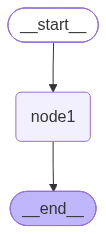

In [6]:
graph=StateGraph(car)
graph.add_node("node1",node)
graph.add_edge(START,"node1")
graph.add_edge("node1",END)
react=graph.compile()
display(Image(react.get_graph().draw_mermaid_png()))

In [7]:
react.invoke({"name":"hey what are you doing?"})

{'name': 'my name is ashwini'}

In [8]:
class Joke(TypedDict):
    topic:str
    joke:str
    improved_joke:str
    final_joke:str

In [9]:
def joke(state:Joke):
    """First llm to Genrate the joke """
    
    message=llm.invoke(f"Give me a joke on {state["topic"]} and somtimes use ? pr ! in the joke. not evreytime")
    return {"joke":message.content}


def imp_joke(state:Joke):
    """Second llm to improve the joke """
    
    message=llm.invoke(f"improve the joke with some wordplay {state["joke"]}")
    return {"improved_joke":message.content}



def final_joke(state:Joke):
    """third llm to add some suprising twist in  the joke """
    
    message=llm.invoke(f"do some surprising twist to make the joke more {state["improved_joke"]}")
    return {"final_joke":message.content}


def punchline(state:Joke):
    
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Fail"
    else:
        return "Pass"

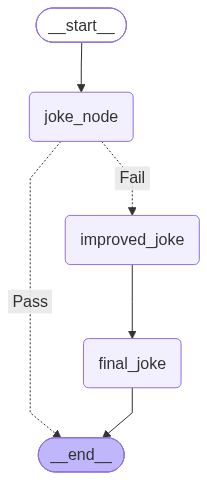

In [10]:
graph=StateGraph(Joke)
graph.add_node("joke_node",joke)
graph.add_node("improved_joke",imp_joke)
graph.add_node("final_joke",final_joke)


graph.add_edge(START,"joke_node")
graph.add_conditional_edges("joke_node",punchline,{"Pass":END,"Fail":"improved_joke"})
graph.add_edge("improved_joke","final_joke")
graph.add_edge("final_joke",END)
graph.add_edge("joke_node",END)
react=graph.compile()
display(Image(react.get_graph().draw_mermaid_png()))

In [11]:
react.invoke({"topic":"cat"})

{'topic': 'cat',
 'joke': 'Why did the cat bring a ladder to the bar?  \nBecause it heard the drinks were on the house!  \nThe bartender asked, “Why the ladder?”  \nThe cat replied, “I just wanted to climb the social ladder—one step at a time.”',
 'improved_joke': '**Why did the cat bring a ladder to the bar?**  \nBecause it heard the drinks were “on the house” and didn’t want to be *just another* cat on the floor.  \n\nThe bartender leaned in and asked, “Why the ladder?”  \n\nThe cat leaned back, tipped its tail, and replied:  \n“Just trying to climb the social ladder—one whisker‑wide step at a time—so I can finally reach the top shelf of the menu.”  \n\n*P.S. The bartender said, “You’re a real *claw-s* in this place!”*',
 'final_joke': '**Why did the cat bring a ladder to the bar?**  \nBecause it heard the drinks were “on the house” and it didn’t want to be *just another* cat on the floor.\n\nThe bartender leaned in and asked, “Why the ladder?”\n\nThe cat leaned back, tipped its tail